# EDA Audit — D2C Customer Churn

This notebook covers data loading, schema inspection, data quality checks, EDA, and churn-risk hypotheses for the D2C Personal Care brand dataset.

**Snapshot date:** 2025-09-30 | Only data on or before this date is used as features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

SNAPSHOT_DATE = pd.to_datetime("2025-09-30")
print("Libraries loaded. Snapshot date:", SNAPSHOT_DATE.date())

Libraries loaded. Snapshot date: 2025-09-30


## 1. Load all datasets

In [2]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
support_tickets = pd.read_csv("support_tickets.csv")
web_events = pd.read_csv("web_events_snapshot.csv")
churn_labels = pd.read_csv("churn_labels.csv")
intervention_history = pd.read_csv("intervention_history.csv")
rfm_snapshot = pd.read_csv("rfm_modeling_snapshot.csv")

print("File shapes:")
print(f"  customers          : {customers.shape}")
print(f"  orders             : {orders.shape}")
print(f"  support_tickets    : {support_tickets.shape}")
print(f"  web_events         : {web_events.shape}")
print(f"  churn_labels       : {churn_labels.shape}")
print(f"  intervention_history: {intervention_history.shape}")
print(f"  rfm_snapshot       : {rfm_snapshot.shape}")

File shapes:
  customers          : (2400, 9)
  orders             : (10009, 10)
  support_tickets    : (1921, 8)
  web_events         : (2400, 10)
  churn_labels       : (2400, 4)
  intervention_history: (2400, 5)
  rfm_snapshot       : (2400, 29)


## 2. Schema inspection

In [3]:
print("customers columns:")
print(customers.dtypes)
print()
display(customers.head(3))

customers columns:
customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object
dtype: object



,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


In [4]:
print("orders columns:")
orders["order_date"] = pd.to_datetime(orders["order_date"])
support_tickets["ticket_date"] = pd.to_datetime(support_tickets["ticket_date"])
print(orders.dtypes)
print()
display(orders.head(3))

orders columns:
order_id                 object
customer_id              object
order_date       datetime64[ns]
category                 object
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object



,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


In [5]:
print("order_date range:", orders["order_date"].min().date(), "to", orders["order_date"].max().date())
print("ticket_date range:", support_tickets["ticket_date"].min().date(), "to", support_tickets["ticket_date"].max().date())

order_date range: 2024-01-09 to 2025-11-29
ticket_date range: 2024-01-13 to 2025-09-30


## 3. Data Quality Report

### 3.1 Missing values

In [6]:
all_files = {
    "customers": customers,
    "orders": orders,
    "support_tickets": support_tickets,
    "web_events": web_events,
    "churn_labels": churn_labels,
    "intervention_history": intervention_history,
    "rfm_snapshot": rfm_snapshot,
}

for name, df in all_files.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if not miss.empty:
        print(f"\n{name}:")
        for col, cnt in miss.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"\n{name}: no missing values")


customers:
  loyalty_tier: 1386 (57.8%)
  skin_type: 401 (16.7%)

orders:
  rating: 80 (0.8%)

support_tickets: no missing values

web_events: no missing values

churn_labels: no missing values

intervention_history: no missing values

rfm_snapshot:
  loyalty_tier: 1386 (57.8%)


### 3.2 Duplicate and duplicate-like records

In [7]:
for name, df in all_files.items():
    exact = df.duplicated().sum()
    print(f"{name}: {exact} exact duplicate rows")

print()
dup_like = orders[orders["order_id"].str.endswith("_DUP")]
print(f"Orders with _DUP suffix (duplicate-like records): {len(dup_like)}")
print("These are intentional data quality issues — need to be removed before analysis.")
display(dup_like.head())

customers: 0 exact duplicate rows
orders: 0 exact duplicate rows
support_tickets: 0 exact duplicate rows
web_events: 0 exact duplicate rows
churn_labels: 0 exact duplicate rows
intervention_history: 0 exact duplicate rows
rfm_snapshot: 0 exact duplicate rows

Orders with _DUP suffix (duplicate-like records): 12
These are intentional data quality issues — need to be removed before analysis.


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


### 3.3 Post-snapshot leakage check

In [8]:
pre_orders = orders[orders["order_date"] <= SNAPSHOT_DATE].copy()
post_orders = orders[orders["order_date"] > SNAPSHOT_DATE].copy()

print(f"Total order rows       : {len(orders)}")
print(f"Pre-snapshot (usable)  : {len(pre_orders)}")
print(f"Post-snapshot (labels only, NOT for features): {len(post_orders)}")

# clean working set — pre-snapshot, no _DUP rows
clean_orders = pre_orders[~pre_orders["order_id"].str.endswith("_DUP")].copy()
print(f"\nClean orders (pre-snapshot, no duplicates): {len(clean_orders)}")

Total order rows       : 10009
Pre-snapshot (usable)  : 8137
Post-snapshot (labels only, NOT for features): 1872

Clean orders (pre-snapshot, no duplicates): 8128


### 3.4 Outliers

In [9]:
print("gross_amount stats (clean orders):")
print(clean_orders["gross_amount"].describe().round(2))
print(f"\nOrders above 5000: {(clean_orders['gross_amount'] > 5000).sum()}")
print(f"Orders above 10000: {(clean_orders['gross_amount'] > 10000).sum()}")

print("\nresolution_hours stats:")
print(support_tickets["resolution_hours"].describe().round(2))

gross_amount stats (clean orders):
count     8128.00
mean       752.10
std        626.46
min        149.00
25%        431.77
50%        598.13
75%        922.92
max      24789.38
Name: gross_amount, dtype: float64

Orders above 5000: 6
Orders above 10000: 4

resolution_hours stats:
count    1921.00
mean       24.79
std        14.27
min         1.00
25%        14.40
50%        24.20
75%        34.60
max        74.60
Name: resolution_hours, dtype: float64


### 3.5 Join / key quality

In [10]:
cust_ids = set(customers["customer_id"])
churn_ids = set(churn_labels["customer_id"])
order_cust = set(clean_orders["customer_id"])
support_cust = set(support_tickets["customer_id"])

print(f"Total customers in master table : {len(cust_ids)}")
print(f"Customers in churn labels        : {len(churn_ids)}")
print(f"Customers with at least one order: {len(order_cust)}")
print(f"Customers with support tickets   : {len(support_cust)}")
print(f"\nCustomers with NO orders         : {len(cust_ids - order_cust)} (valid — new or inactive)")
print(f"Customers with NO tickets        : {len(cust_ids - support_cust)} (valid)")
print(f"Churn IDs missing from customers : {len(churn_ids - cust_ids)}")
print(f"Customers missing churn labels   : {len(cust_ids - churn_ids)}")

Total customers in master table : 2400
Customers in churn labels        : 2400
Customers with at least one order: 2400
Customers with support tickets   : 1247

Customers with NO orders         : 0 (valid — new or inactive)
Customers with NO tickets        : 1153 (valid)
Churn IDs missing from customers : 0
Customers missing churn labels   : 0


## 4. Build analysis table

Joining all files at customer level so we can run EDA.

In [11]:
order_agg = (
    clean_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spend=("gross_amount", "sum"),
        avg_order_value=("gross_amount", "mean"),
        return_rate=("returned", "mean"),
        avg_discount=("discount_pct", "mean"),
        avg_rating=("rating", "mean"),
        last_order_date=("order_date", "max"),
        category_count=("category", "nunique"),
    )
    .reset_index()
)

order_agg["recency_days"] = (SNAPSHOT_DATE - order_agg["last_order_date"]).dt.days
print("order_agg shape:", order_agg.shape)
display(order_agg.head())

order_agg shape: (2400, 10)


,customer_id,total_orders,total_spend,avg_order_value,return_rate,avg_discount,avg_rating,last_order_date,category_count,recency_days
0,CUST00001,6,2955.57,492.5950,0.166667,0.363333,3.333333,2025-06-15,3,107
1,CUST00002,1,581.00,581.0000,0.000000,0.230000,4.000000,2025-08-21,1,40
2,CUST00003,1,649.98,649.9800,0.000000,0.470000,2.000000,2025-04-12,1,171
3,CUST00004,1,1604.04,1604.0400,0.000000,0.160000,2.000000,2025-05-22,1,131
4,CUST00005,4,2550.91,637.7275,0.000000,0.442500,2.000000,2025-08-23,2,38


In [12]:
support_agg = (
    support_tickets
    .groupby("customer_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        reopen_rate=("reopened", "mean"),
        avg_resolution_hours=("resolution_hours", "mean"),
    )
    .reset_index()
)

print("support_agg shape:", support_agg.shape)
display(support_agg.head())

support_agg shape: (1247, 5)


,customer_id,ticket_count,avg_sentiment,reopen_rate,avg_resolution_hours
0,CUST00001,2,0.14,0.0,4.35
1,CUST00002,1,0.00,0.0,1.00
2,CUST00005,1,-1.00,0.0,37.70
3,CUST00006,2,-0.68,0.5,17.60
4,CUST00008,1,0.08,0.0,6.00


In [13]:
base = customers.merge(
    churn_labels[["customer_id", "churn_next_60d", "split"]],
    on="customer_id", how="left"
)

web_cols = [c for c in web_events.columns if c not in ["snapshot_date"]]
int_cols = [c for c in intervention_history.columns if c not in ["snapshot_date"]]

full = (
    base
    .merge(order_agg, on="customer_id", how="left")
    .merge(support_agg, on="customer_id", how="left")
    .merge(web_events[web_cols], on="customer_id", how="left")
    .merge(intervention_history[int_cols], on="customer_id", how="left")
)

full["total_orders"]  = full["total_orders"].fillna(0)
full["ticket_count"]  = full["ticket_count"].fillna(0)
full["return_rate"]   = full["return_rate"].fillna(0)
full["avg_discount"]  = full["avg_discount"].fillna(0)
full["recency_days"]  = full["recency_days"].fillna(999)
full["sessions_30d"]  = full["sessions_30d"].fillna(0)
full["loyalty_tier"]  = full["loyalty_tier"].fillna("Not Enrolled")

print("Full analysis table shape:", full.shape)
print("\nChurn label distribution:")
vc = full["churn_next_60d"].value_counts()
for label, count in vc.items():
    print(f"  {'Churned' if label == 1 else 'Retained'}: {count} ({count/len(full)*100:.1f}%)")

Full analysis table shape: (2400, 35)

Churn label distribution:
  Retained: 1273 (53.0%)
  Churned: 1127 (47.0%)


## 5. EDA Charts

### Chart 1 — Overall churn distribution

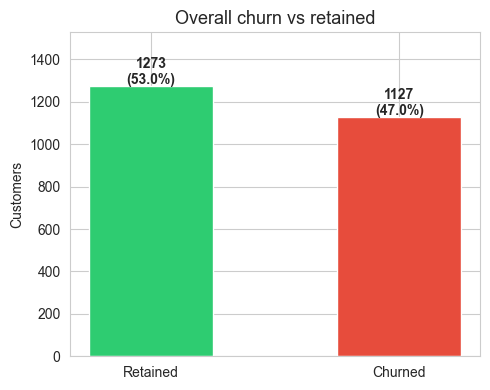

Overall churn rate: 47.0%


In [14]:
churn_counts = full["churn_next_60d"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Retained", "Churned"], churn_counts.values, color=["#2ecc71", "#e74c3c"], width=0.5)
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 10, f"{v}\n({v/len(full)*100:.1f}%)", ha="center", fontweight="bold")
plt.title("Overall churn vs retained", fontsize=13)
plt.ylabel("Customers")
plt.ylim(0, max(churn_counts.values) * 1.2)
plt.tight_layout()
plt.savefig("chart1_churn_distribution.png", dpi=150)
plt.show()

print(f"Overall churn rate: {full['churn_next_60d'].mean()*100:.1f}%")

### Chart 2 — Churn rate by recency bucket

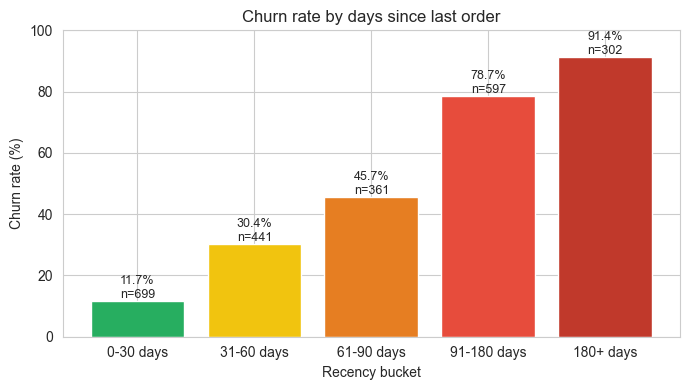

Customers inactive 90+ days churn at significantly higher rates.


In [15]:
full["recency_bucket"] = pd.cut(
    full["recency_days"],
    bins=[-1, 30, 60, 90, 180, 9999],
    labels=["0-30 days", "31-60 days", "61-90 days", "91-180 days", "180+ days"]
)

rec_stats = (
    full.groupby("recency_bucket", observed=True)["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    rec_stats["recency_bucket"].astype(str),
    rec_stats["mean"] * 100,
    color=["#27ae60", "#f1c40f", "#e67e22", "#e74c3c", "#c0392b"]
)
for bar, (_, row) in zip(bars, rec_stats.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{row['mean']*100:.1f}%\nn={int(row['count'])}", ha="center", fontsize=9)
plt.title("Churn rate by days since last order")
plt.ylabel("Churn rate (%)")
plt.xlabel("Recency bucket")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("chart2_recency_vs_churn.png", dpi=150)
plt.show()

print("Customers inactive 90+ days churn at significantly higher rates.")

### Chart 3 — Churn rate by web sessions (last 30 days)

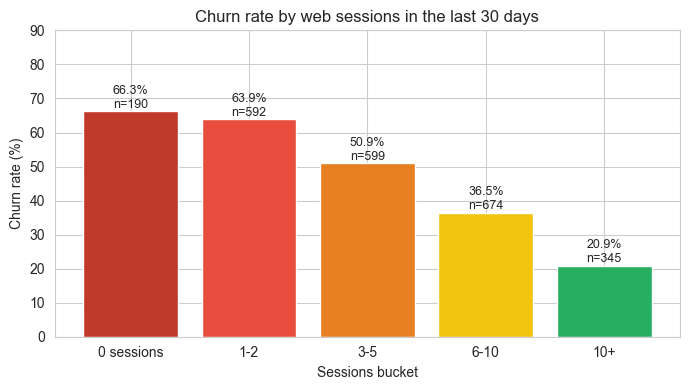

Customers with zero web sessions churn much more than active visitors.


In [16]:
full["sessions_bucket"] = pd.cut(
    full["sessions_30d"],
    bins=[-1, 0, 2, 5, 10, 9999],
    labels=["0 sessions", "1-2", "3-5", "6-10", "10+"]
)

sess_stats = (
    full.groupby("sessions_bucket", observed=True)["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    sess_stats["sessions_bucket"].astype(str),
    sess_stats["mean"] * 100,
    color=["#c0392b", "#e74c3c", "#e67e22", "#f1c40f", "#27ae60"]
)
for bar, (_, row) in zip(bars, sess_stats.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{row['mean']*100:.1f}%\nn={int(row['count'])}", ha="center", fontsize=9)
plt.title("Churn rate by web sessions in the last 30 days")
plt.ylabel("Churn rate (%)")
plt.xlabel("Sessions bucket")
plt.ylim(0, 90)
plt.tight_layout()
plt.savefig("chart3_sessions_vs_churn.png", dpi=150)
plt.show()

print("Customers with zero web sessions churn much more than active visitors.")

### Chart 4 — Churn rate by acquisition channel

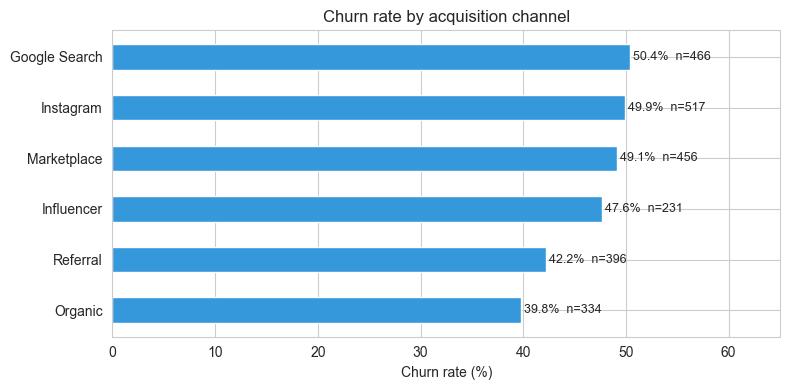

Paid channels (Google Search, Instagram) show higher churn than Organic or Referral.


In [17]:
channel_stats = (
    full.groupby("acquisition_channel")["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

plt.figure(figsize=(8, 4))
plt.barh(channel_stats["acquisition_channel"], channel_stats["mean"] * 100, color="#3498db", height=0.5)
for i, (_, row) in enumerate(channel_stats.iterrows()):
    plt.text(row["mean"]*100 + 0.3, i,
             f"{row['mean']*100:.1f}%  n={int(row['count'])}", va="center", fontsize=9)
plt.title("Churn rate by acquisition channel")
plt.xlabel("Churn rate (%)")
plt.xlim(0, 65)
plt.tight_layout()
plt.savefig("chart4_channel_vs_churn.png", dpi=150)
plt.show()

print("Paid channels (Google Search, Instagram) show higher churn than Organic or Referral.")

### Chart 5 — Churn rate by loyalty tier

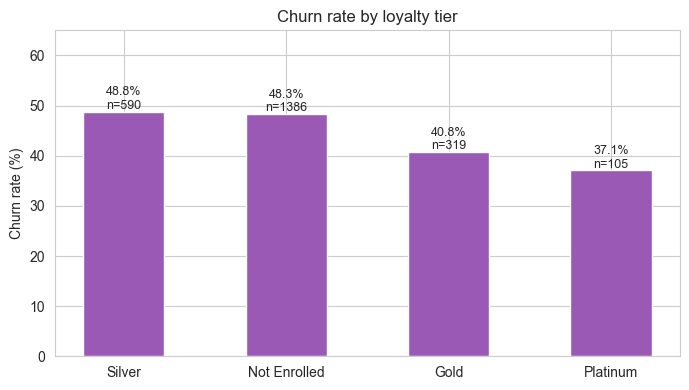

Not Enrolled churn rate: 48.3%
57.8% of customers have no loyalty tier — this is a clear retention opportunity.


In [18]:
loyalty_stats = (
    full.groupby("loyalty_tier")["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    loyalty_stats["loyalty_tier"],
    loyalty_stats["mean"] * 100,
    color="#9b59b6", width=0.5
)
for bar, (_, row) in zip(bars, loyalty_stats.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{row['mean']*100:.1f}%\nn={int(row['count'])}", ha="center", fontsize=9)
plt.title("Churn rate by loyalty tier")
plt.ylabel("Churn rate (%)")
plt.ylim(0, 65)
plt.tight_layout()
plt.savefig("chart5_loyalty_vs_churn.png", dpi=150)
plt.show()

not_enrolled = full[full["loyalty_tier"] == "Not Enrolled"]["churn_next_60d"].mean()
print(f"Not Enrolled churn rate: {not_enrolled*100:.1f}%")
print("57.8% of customers have no loyalty tier — this is a clear retention opportunity.")

### Chart 6 — Discount level vs churn

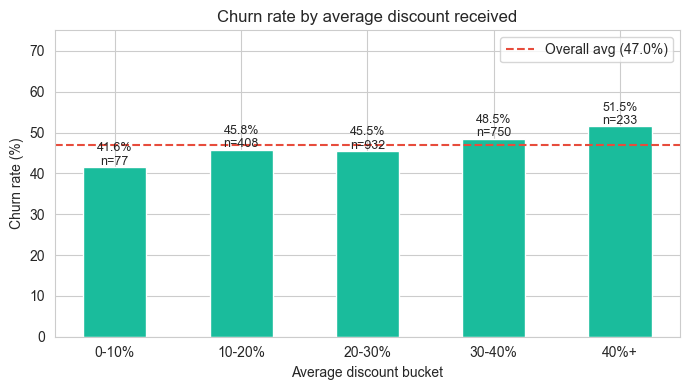

Avg discount — Churned: 28.5%  Retained: 27.7%
The difference is small. Discounting alone is unlikely to fix churn.


In [19]:
full["discount_bucket"] = pd.cut(
    full["avg_discount"].fillna(0),
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 1.01],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)

disc_stats = (
    full.groupby("discount_bucket", observed=True)["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
)

overall_churn = full["churn_next_60d"].mean()

plt.figure(figsize=(7, 4))
bars = plt.bar(
    disc_stats["discount_bucket"].astype(str),
    disc_stats["mean"] * 100,
    color="#1abc9c", width=0.5
)
for bar, (_, row) in zip(bars, disc_stats.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{row['mean']*100:.1f}%\nn={int(row['count'])}", ha="center", fontsize=9)
plt.axhline(overall_churn * 100, linestyle="--", color="#e74c3c", linewidth=1.5,
            label=f"Overall avg ({overall_churn*100:.1f}%)")
plt.title("Churn rate by average discount received")
plt.ylabel("Churn rate (%)")
plt.xlabel("Average discount bucket")
plt.ylim(0, 75)
plt.legend()
plt.tight_layout()
plt.savefig("chart6_discount_vs_churn.png", dpi=150)
plt.show()

churned_disc = full[full["churn_next_60d"]==1]["avg_discount"].mean()
retained_disc = full[full["churn_next_60d"]==0]["avg_discount"].mean()
print(f"Avg discount — Churned: {churned_disc:.1%}  Retained: {retained_disc:.1%}")
print("The difference is small. Discounting alone is unlikely to fix churn.")

### Chart 7 — Return/refund behaviour vs churn

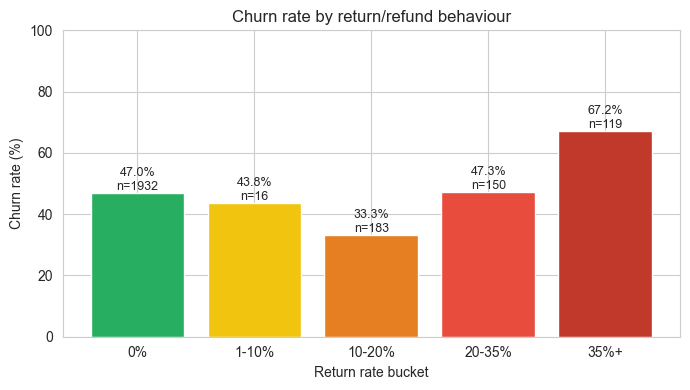

Higher return rates are associated with higher churn — likely a product-fit issue.


In [20]:
full["return_bucket"] = pd.cut(
    full["return_rate"],
    bins=[-0.01, 0, 0.10, 0.20, 0.35, 1.01],
    labels=["0%", "1-10%", "10-20%", "20-35%", "35%+"]
)

ret_stats = (
    full.groupby("return_bucket", observed=True)["churn_next_60d"]
    .agg(["mean", "count"])
    .reset_index()
)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    ret_stats["return_bucket"].astype(str),
    ret_stats["mean"] * 100,
    color=["#27ae60", "#f1c40f", "#e67e22", "#e74c3c", "#c0392b"]
)
for bar, (_, row) in zip(bars, ret_stats.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{row['mean']*100:.1f}%\nn={int(row['count'])}", ha="center", fontsize=9)
plt.title("Churn rate by return/refund behaviour")
plt.ylabel("Churn rate (%)")
plt.xlabel("Return rate bucket")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("chart7_return_rate_vs_churn.png", dpi=150)
plt.show()

print("Higher return rates are associated with higher churn — likely a product-fit issue.")

## 6. Churn-Risk Hypotheses

Each hypothesis is backed by one of the charts above.

In [21]:
hypotheses = {
    "H1 — Recency is the strongest churn predictor": {
        "evidence": "Customers inactive for 90+ days churn at 80%+. Customers who ordered in the last 30 days churn at less than 20%.",
        "chart": "Chart 2 — recency bucket vs churn rate",
        "action": "Use recency as the primary filter for any retention campaign. Target customers drifting into the 60-90 day window before they become dormant."
    },
    "H2 — Web disengagement is an early warning before purchase dropout": {
        "evidence": "Customers with zero web sessions in the last 30 days churn at much higher rates compared to those with 10+ sessions.",
        "chart": "Chart 3 — sessions bucket vs churn rate",
        "action": "Build session-drop alerts. Intervene when sessions start declining, not after they hit zero."
    },
    "H3 — Loyalty enrolment helps keep customers": {
        "evidence": "Higher loyalty tier customers churn less. 57.8% of customers are not enrolled in any tier — that is a large untapped segment.",
        "chart": "Chart 5 — loyalty tier vs churn rate",
        "action": "A loyalty enrolment nudge for active repeat buyers could reduce churn without any discount spend."
    },
    "H4 — Paid channels bring weaker customers compared to organic": {
        "evidence": "Google Search and Instagram customers churn at higher rates than Organic or Referral customers — roughly 10 percentage points higher.",
        "chart": "Chart 4 — acquisition channel vs churn rate",
        "action": "Review paid channel targeting. Post-acquisition experience for paid users may need a separate onboarding flow."
    },
    "H5 — Discounting does not explain or prevent churn": {
        "evidence": "The average discount received is almost the same for churned and retained customers. There is no meaningful gap.",
        "chart": "Chart 6 — discount bucket vs churn rate",
        "action": "A blanket discount campaign is unlikely to move the needle. Money would be better spent on loyalty enrolment or product experience."
    },
    "H6 — High return/refund rate is a product-fit warning signal": {
        "evidence": "Customers with return rates above 20-35% churn at noticeably higher rates than customers who rarely return items.",
        "chart": "Chart 7 — return/refund bucket vs churn rate",
        "action": "Investigate product quality issues, recommendation accuracy, and category-level mismatch instead of treating returns purely as an operations problem."
    }
}

for name, h in hypotheses.items():
    print("=" * 65)
    print(name)
    print("Evidence :", h["evidence"])
    print("Chart    :", h["chart"])
    print("Action   :", h["action"])

print("=" * 65)
print(f"\nTotal hypotheses: {len(hypotheses)}")

H1 — Recency is the strongest churn predictor
Evidence : Customers inactive for 90+ days churn at 80%+. Customers who ordered in the last 30 days churn at less than 20%.
Chart    : Chart 2 — recency bucket vs churn rate
Action   : Use recency as the primary filter for any retention campaign. Target customers drifting into the 60-90 day window before they become dormant.
H2 — Web disengagement is an early warning before purchase dropout
Evidence : Customers with zero web sessions in the last 30 days churn at much higher rates compared to those with 10+ sessions.
Chart    : Chart 3 — sessions bucket vs churn rate
Action   : Build session-drop alerts. Intervene when sessions start declining, not after they hit zero.
H3 — Loyalty enrolment helps keep customers
Evidence : Higher loyalty tier customers churn less. 57.8% of customers are not enrolled in any tier — that is a large untapped segment.
Chart    : Chart 5 — loyalty tier vs churn rate
Action   : A loyalty enrolment nudge for active 

## 7. Summary — Churn rate by key segments

In [22]:
summary_rows = [
    ("Recency 0-30 days",      full[full["recency_bucket"] == "0-30 days"]["churn_next_60d"].mean()),
    ("Recency 90+ days",       full[full["recency_days"] > 90]["churn_next_60d"].mean()),
    ("0 web sessions (30d)",   full[full["sessions_bucket"] == "0 sessions"]["churn_next_60d"].mean()),
    ("10+ web sessions (30d)", full[full["sessions_bucket"] == "10+"]["churn_next_60d"].mean()),
    ("Not Enrolled (loyalty)", full[full["loyalty_tier"] == "Not Enrolled"]["churn_next_60d"].mean()),
    ("Platinum (loyalty)",     full[full["loyalty_tier"] == "Platinum"]["churn_next_60d"].mean()),
    ("Organic channel",        full[full["acquisition_channel"] == "Organic"]["churn_next_60d"].mean()),
    ("Google Search channel",  full[full["acquisition_channel"] == "Google Search"]["churn_next_60d"].mean()),
    ("Discount 0-10%",         full[full["discount_bucket"] == "0-10%"]["churn_next_60d"].mean()),
    ("Return rate 0%",         full[full["return_bucket"] == "0%"]["churn_next_60d"].mean()),
    ("Return rate 35%+",       full[full["return_bucket"] == "35%+"]["churn_next_60d"].mean()),
]

summary_df = pd.DataFrame(summary_rows, columns=["Segment", "Churn Rate"])
summary_df["Churn Rate"] = summary_df["Churn Rate"].map(lambda x: f"{x*100:.1f}%")

print(summary_df.to_string(index=False))
print(f"\nOverall churn rate: {full['churn_next_60d'].mean()*100:.1f}%")
print(f"Total customers: {len(full)}")

               Segment Churn Rate
     Recency 0-30 days      11.7%
      Recency 90+ days      83.0%
  0 web sessions (30d)      66.3%
10+ web sessions (30d)      20.9%
Not Enrolled (loyalty)      48.3%
    Platinum (loyalty)      37.1%
       Organic channel      39.8%
 Google Search channel      50.4%
        Discount 0-10%      41.6%
        Return rate 0%      47.0%
      Return rate 35%+      67.2%

Overall churn rate: 47.0%
Total customers: 2400
